In [2]:
#1. Load Dataset
#2. Check missing,if there handle it
#3. Check if numeric,if not convert to numeric
#4. Seperate features and target
#5. Scalling(Standard Scaler,minmax scaler)
#6. Train Test Split
#7. Model creation
# check performance(accuracy,f1score.....)
#9. predict new value

In [3]:
import numpy as np
import pandas as pd
df=pd.read_csv('/content/drive/MyDrive/Datasets/lung_cancer_examples.csv')
df

,Name,Surname,Age,Smokes,AreaQ,Alkhol,Result
0,John,Wick,35,3,5,4,1
1,John,Constantine,27,20,2,5,1
2,Camela,Anderson,30,0,5,2,0
3,Alex,Telles,28,0,8,1,0
4,Diego,Maradona,68,4,5,6,1
5,Cristiano,Ronaldo,34,0,10,0,0
6,Mihail,Tal,58,15,10,0,0
7,Kathy,Bates,22,12,5,2,0
8,Nicole,Kidman,45,2,6,0,0
9,Ray,Milland,52,18,4,5,1


In [4]:
df.isna().sum()

,0
Name,0
Surname,0
Age,0
Smokes,0
AreaQ,0
Alkhol,0
Result,0


In [5]:
df.dtypes

,0
Name,object
Surname,object
Age,int64
Smokes,int64
AreaQ,int64
Alkhol,int64
Result,int64


In [6]:
df.drop(['Name','Surname'],axis=1,inplace=True)
df

,Age,Smokes,AreaQ,Alkhol,Result
0,35,3,5,4,1
1,27,20,2,5,1
2,30,0,5,2,0
3,28,0,8,1,0
4,68,4,5,6,1
5,34,0,10,0,0
6,58,15,10,0,0
7,22,12,5,2,0
8,45,2,6,0,0
9,52,18,4,5,1


In [7]:
X=df.iloc[:,:-1]
X

,Age,Smokes,AreaQ,Alkhol
0,35,3,5,4
1,27,20,2,5
2,30,0,5,2
3,28,0,8,1
4,68,4,5,6
5,34,0,10,0
6,58,15,10,0
7,22,12,5,2
8,45,2,6,0
9,52,18,4,5


In [8]:
Y=df['Result']
Y

,Result
0,1
1,1
2,0
3,0
4,1
5,0
6,0
7,0
8,0
9,1


In [9]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X_scaled=scaler.fit_transform(X)

In [10]:
from sklearn.model_selection import train_test_split
X_tr,X_te,Y_tr,Y_te=train_test_split(X_scaled,Y,test_size=0.30,random_state=13)

In [11]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier()
knn.fit(X_tr,Y_tr)
pred=knn.predict(X_te)

In [12]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,ConfusionMatrixDisplay
print(accuracy_score(Y_te,pred))


0.9444444444444444


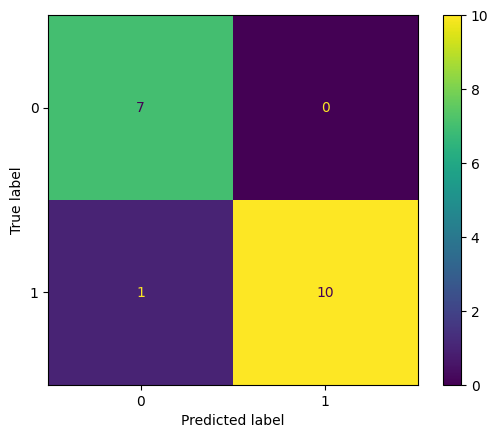

In [13]:
print(ConfusionMatrixDisplay.from_predictions(Y_te,pred))

In [14]:
print(classification_report(Y_te,pred))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       1.00      0.91      0.95        11

    accuracy                           0.94        18
   macro avg       0.94      0.95      0.94        18
weighted avg       0.95      0.94      0.94        18



In [15]:
y_new=knn.predict(scaler.transform([[18,10,6,3]]))
if y_new==0:
  print("no cancer , enjoy")
else:
  print("I'm sorry , cancer cnfrm" )

no cancer , enjoy


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [16]:
from sklearn.model_selection import train_test_split
X_tr,X_te,Y_tr,Y_te=train_test_split(X,Y,test_size=0.30,random_state=13)

In [17]:
from sklearn.naive_bayes import GaussianNB
gnb=GaussianNB()
gnb.fit(X_tr,Y_tr)
pred_gnb=gnb.predict(X_te)

In [18]:
print(classification_report(Y_te,pred_gnb))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93         7
           1       1.00      0.91      0.95        11

    accuracy                           0.94        18
   macro avg       0.94      0.95      0.94        18
weighted avg       0.95      0.94      0.94        18



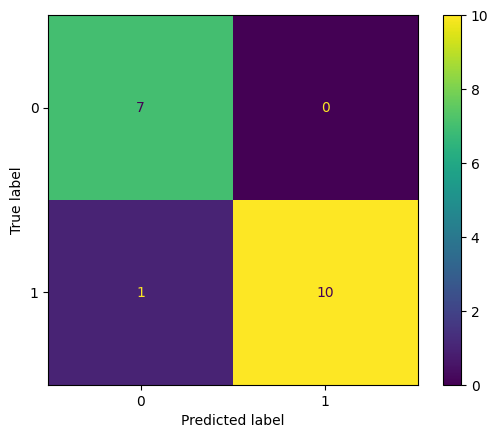

In [19]:
print(ConfusionMatrixDisplay.from_predictions(Y_te,pred_gnb))

In [20]:
y_ne=gnb.predict([[18,10,6,3]])
if y_ne==0:
  print("no cancer ")
else:
  print("I'm sorry , cancer cnfrm" )

no cancer 


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


In [21]:
gnb.score(X_tr,Y_tr)

1.0

In [22]:
import pickle
pickle.dump(knn,open('modellc.sav','wb'))
pickle.dump(scaler,open('scacler.sav','wb'))

In [23]:
!pip list

Package                                  Version
---------------------------------------- -------------------
absl-py                                  1.4.0
accelerate                               1.12.0
access                                   1.1.10.post3
affine                                   2.4.0
aiofiles                                 24.1.0
aiohappyeyeballs                         2.6.1
aiohttp                                  3.13.3
aiosignal                                1.4.0
aiosqlite                                0.22.1
alabaster                                1.0.0
albucore                                 0.0.24
albumentations                           2.0.8
ale-py                                   0.11.2
alembic                                  1.18.4
altair                                   5.5.0
annotated-doc                            0.0.4
annotated-types                          0.7.0
antlr4-python3-runtime                   4.9.3
anyio                         

In [25]:
preddd=knn.predict(scaler.transform([[77,20,5,4]]))
preddd

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


array([1])